# Comparison of path with nexstrain


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
import matplotlib as mpl
import os
import matplotlib.dates as mdates
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from sklearn.metrics import roc_curve, auc


from utils_mean_field import *
from script_mean_field_covid import *
# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
ab_names=list(ESCAPE_VECTORS.keys())


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [2]:
rbd_df=pd.read_csv('../covid/gisaid/rbd_df.csv')
rbd_df.columns

Index(['sequence', 'count', 'date_of_100th', 'q05_date'], dtype='object')

In [3]:
# 2. Convert DataFrame rows to SeqRecord objects
records = []
for index, row in rbd_df.iterrows():
    # You can change str(index) to row['id_column'] if you have one
    records.append(SeqRecord(
        Seq(row['sequence']),
        id=str(index),
        description="" # Keeps the header clean (just >0, >1, etc.)
    ))

# 3. Write to file
output_file = "../covid/gisaid/sequences_rbd_df.fasta"
SeqIO.write(records, output_file, "fasta")

print(f"Successfully created {output_file}")

Successfully created ../covid/gisaid/sequences_rbd_df.fasta


# Order params

In [4]:
wt_seq=WT[BEGIN:-END]
dir = '../mean_field_theory/results_scripts/covid_D_20/'
paths=['mean_f_free_ab_beta_ab_0_D_1.npy', 'mean_f_free_ab_beta_ab_1_D_1.npy', 'mean_f_free_ab_beta_ab_5_D_1.npy']
labels=['beta_Ab=0','beta_Ab=1','beta_Ab=5' ]

In [5]:


# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# --- CONFIGURATION ---
THRESHOLD = 0.005  # Define your probability threshold here
# ---------------------



path_mutations_all = {} # variant -> set[str] (Any mutation > TH along the path)

for i, condition in enumerate(labels):

    # Load and compute mutation
    # Assumed shape based on argmax usage: (Vocab_Size, Sequence_Length, Time_Steps)
    path_proba = np.load(os.path.join(dir, paths[i])) # shape Q,T,L. Step is T
    print(f"Processing: {condition}")
    current_path_set = set()

    for step in range(path_proba.shape[1]):
      
        path_proba_step = path_proba[:, step, :]
        for site in range(path_proba_step.shape[1]):
            for aa in range(path_proba_step.shape[0]):
                prob = path_proba_step[aa, site]
                if prob > THRESHOLD:
                    wt_aa = wt_seq[site]
                    mut_aa = Proteins_utils.num2seq(np.array([aa]))
                    mutation = f"{wt_aa}{349 + site}{mut_aa}"
                    if mut_aa != wt_aa:

                        current_path_set.add(mutation)

 
    path_mutations_all[condition] = current_path_set
    print(f"Mutations for {condition}: {current_path_set}\n")
# Display results



Processing: beta_Ab=0
Mutations for beta_Ab=0: {'T385E', 'A520L', 'S477G', 'I410L', 'N440E', 'S375G', 'Y365I', 'G496H', 'T376R', 'A363F', 'C391S', 'G496S', 'V382E', 'S383T', 'N460K', 'C525S', 'F374W', 'V367Q', 'C525R', 'A372K', 'C525K', 'L390Q', 'G496M', 'R466K', 'N450T', 'A520E', 'N487D', 'N440D', 'S383D', 'Q498H', 'H519A', 'R408K', 'R357T', 'N394K', 'S373D', 'T376K', 'G496V', 'A363L', 'V367E', 'L390K', 'F490Y', 'C525T', 'Q493R', 'V367K', 'N440H', 'N440A', 'L517E', 'S375N', 'K417V', 'R457A', 'G496L', 'D389K', 'L517K', 'S477N', 'S373K', 'S383A', 'L517D', 'Y449F', 'L518T', 'N394T', 'C391T'}

Processing: beta_Ab=1
Mutations for beta_Ab=1: {'T385E', 'N394T', 'L452E', 'S477G', 'G496H', 'N487R', 'Y365I', 'S375G', 'T376R', 'A363F', 'D428N', 'K378E', 'C391S', 'G496S', 'V382E', 'R357E', 'A363W', 'S383T', 'C525S', 'F374W', 'V367Q', 'S383E', 'C525R', 'A372K', 'C525K', 'G496M', 'R466K', 'N450T', 'A520E', 'N487D', 'N440D', 'H519D', 'F486P', 'S383D', 'K356T', 'V445D', 'G496W', 'Q498H', 'S514R', 'K4

Loading GISAID summary...
Computing curve for beta_Ab=0 (61 mutations)...
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 5 5 5 5 5 5 5 5 5 6 6 6 6 6 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 8 8 8 8 8 8]
Computing curve for beta_Ab=1 (74 mutations)...
[ 3  3  3  3  3  3  3  3  3  3  3  3  3  3  4  5  5  5  5  5  5  5  6  6
  7  7  8  8  8  9  9  9 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11]
Computing curve for beta_Ab=5 (67 mutations)...
[ 2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  2  3  4
  5  5  6  6  6  8  8  8  9 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 11 11 11 11 11 11]
[  58   58   58   63   77   89  105  126  146  178  216  261  314  388
  467  586  687  746  803  887 1028 1189 1365 1551 1672 1752 1813 1888
 1922 1965 1990 2020 2040 2060 2082 2107 2123 2151 2169 2184 2198 2205
 2209 2217 2228 2240 2247 2257 2266 2273 2274 2275 2279 2280 2287 2293
 2298 2

<>:94: SyntaxWarning: invalid escape sequence '\%'
<>:94: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\171251391.py:94: SyntaxWarning: invalid escape sequence '\%'
  ylabel = "Cumulative \% observed" if NORMALIZE else "Cumulative count observed"


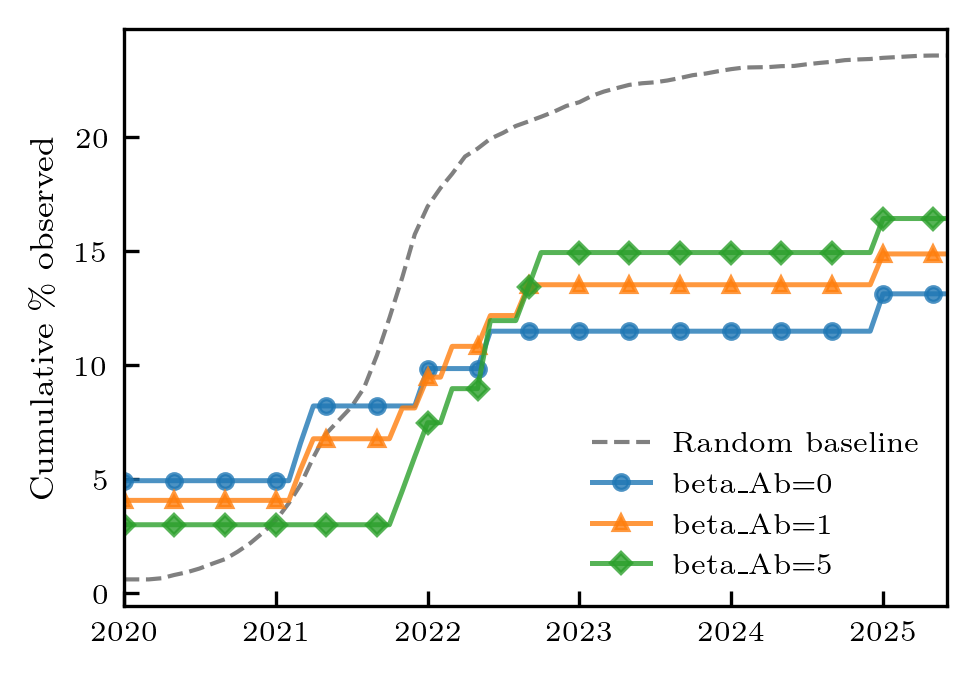

In [6]:

# --- SETTINGS ---
NORMALIZE = True  # Set to True for Percentage (%), False for Raw Count
GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"

# Style settings (from your snippet)
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 600,
    "axes.linewidth": 0.8, "lines.linewidth": 1.2, "lines.markersize": 3.5,
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "text.usetex": True
})

# 1. Load and Preprocess GISAID Data
# -------------------------------------------------------
print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)
df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

# Filter to mutations that have actually been observed (valid date)
# We create a dictionary {mutation_string: date} for O(1) lookup speed
df_seen = df_base.dropna(subset=["first_seen_100"])
mut_date_map = pd.Series(df_seen.first_seen_100.values, index=df_seen.mutation).to_dict()

# 2. Define Time Axis (Global)
# -------------------------------------------------------
global_start = df_seen["first_seen_100"].min()
global_end = df_seen["first_seen_100"].max()
global_months = pd.date_range(global_start, global_end, freq="MS")

def get_cumulative_curve(mutations_set, date_map, month_grid, normalize=True):
    """
    Calculates the cumulative curve for a set of mutations.
    """
    # 1. Identify which predicted mutations were observed
    # Intersection is much faster than loop for large sets
    observed_muts = mutations_set.intersection(date_map.keys())
    
    # 2. Extract the dates for these hits
    dates = [date_map[m] for m in observed_muts]
    dates = np.sort(np.array(dates, dtype="datetime64[ns]"))
    
    # 3. Count how many happened before each month step
    months64 = month_grid.to_numpy("datetime64[ns]")
    counts = np.searchsorted(dates, months64, side="right")
    print(counts)
    if normalize:
        if len(mutations_set) == 0: return np.zeros(len(month_grid))
        return (counts / len(mutations_set)) * 100.0
    else:
        return counts

# 3. Compute Curves for Each Condition
# -------------------------------------------------------
curves = {}
for condition, mut_set in path_mutations_all.items():
    print(f"Computing curve for {condition} ({len(mut_set)} mutations)...")
    curves[condition] = get_cumulative_curve(mut_set, mut_date_map, global_months, normalize=NORMALIZE)

# Optional: Random Baseline (all mutations in database)
# Matches 'avg_rnd' logic from your snippet
all_possible_muts = set(df_base["mutation"].unique())
# Denom is len(df_base) to represent % of 'all known mutations'
random_curve = get_cumulative_curve(all_possible_muts, mut_date_map, global_months, normalize=False)
if NORMALIZE:
    random_curve = (random_curve / len(df_base)) * 100.0

# 4. Plotting
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.5, 2.5))

markers = ["o", "^", "D", "s", "v"]
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"] # Matplotlib defaults

# Plot Random Baseline first (so it's at the back)
ax.plot(global_months, random_curve, marker="None", ls="--", color="gray", label="Random baseline", lw=1)

# Plot Conditions
for i, (condition, y_values) in enumerate(curves.items()):
    style_idx = i % len(markers)
    ax.plot(global_months, y_values, 
            marker=markers[style_idx], 
            label=condition,
            color=colors[style_idx],
            markevery=4, # Don't clutter with markers
            alpha=0.8)

# Formatting
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", labelrotation=0)

ylabel = "Cumulative \% observed" if NORMALIZE else "Cumulative count observed"
ax.set_ylabel(ylabel)
ax.tick_params(direction="in", which="both", top=False, right=False)
ax.legend(frameon=False, loc="best")

# 5. Add Train/Prediction Arrows (from your snippet)
# -------------------------------------------------------
# We need to manually set limits or get them to place arrows correctly
x0_num, x1_num = mdates.date2num(global_start), mdates.date2num(global_end)
ax.set_xlim(global_start, global_end)




plt.tight_layout(pad=2.0) # Add padding for the arrows below
plt.show()

# Site wise analysis

In [7]:

# import Proteins_utils # Assuming this is imported in your environment

# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# --- CONFIGURATION ---
THRESHOLD = 0.005  # Define your probability threshold here
# ---------------------
SITE_OFFSET = 349  # Residue numbering offset

path_mutations_all = {} # variant -> set[str] (Any mutation > TH along the path)
path_entropies_all = {} # condition -> array of entropies per site (Last step)

for i, condition in enumerate(labels):

    # Load and compute mutation
    # Assumed shape based on your comment: (Vocab_Size, Time_Steps, Sequence_Length)
    # Q, T, L
    path_proba = np.load(os.path.join(dir, paths[i])) 
    print(f"Processing: {condition}")

    # --- NEW: Compute Entropy at the Last Step ---
    # 1. Get probabilities at the last time step (Index -1 on axis 1)
    # Shape becomes (Vocab_Size, Sequence_Length)
    last_step_probs = path_proba[:, -1, :]
    
    # 2. Compute Entropy: H = - sum(p * log(p))
    # We add a tiny epsilon (1e-12) to avoid log(0) errors (yielding -inf)
    epsilon = 1e-12
    # Sum over axis 0 (Amino Acids) to get one entropy value per site
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
    # Store the result
    path_entropies_all[condition] = site_entropies
    print(f"Computed entropies for {len(site_entropies)} sites at last step.")
    print(f"Mean Entropy: {np.mean(site_entropies):.4f}\n")
    # ---------------------------------------------



    print(f"Top 20 sites by entropy for {condition}:")
    top_indices=np.argsort(site_entropies)[-20:]
    for idx in top_indices:
        site_number = SITE_OFFSET + idx  # Adjust for residue numbering offset
        entropy_value = site_entropies[idx]
        print(f"Site {site_number}: Entropy = {entropy_value:.4f}")
    print("\n")

path_entropies_all

Processing: beta_Ab=0
Computed entropies for 178 sites at last step.
Mean Entropy: 0.0607

Top 20 sites by entropy for beta_Ab=0:
Site 389: Entropy = 0.1343
Site 520: Entropy = 0.1538
Site 376: Entropy = 0.1611
Site 457: Entropy = 0.1636
Site 477: Entropy = 0.1869
Site 373: Entropy = 0.2438
Site 493: Entropy = 0.2443
Site 390: Entropy = 0.2485
Site 408: Entropy = 0.2524
Site 383: Entropy = 0.2535
Site 382: Entropy = 0.2668
Site 375: Entropy = 0.2987
Site 367: Entropy = 0.3069
Site 460: Entropy = 0.3623
Site 517: Entropy = 0.4085
Site 525: Entropy = 0.5443
Site 385: Entropy = 0.7071
Site 391: Entropy = 0.8296
Site 440: Entropy = 0.9770
Site 496: Entropy = 1.0628


Processing: beta_Ab=1
Computed entropies for 178 sites at last step.
Mean Entropy: 0.0731

Top 20 sites by entropy for beta_Ab=1:
Site 445: Entropy = 0.1809
Site 487: Entropy = 0.1946
Site 382: Entropy = 0.2057
Site 514: Entropy = 0.2354
Site 440: Entropy = 0.2638
Site 517: Entropy = 0.2718
Site 383: Entropy = 0.2842
Site 525:

{'beta_Ab=0': array([8.68948662e-04, 3.15642779e-04, 8.32344644e-03, 3.32690904e-02,
        1.42139819e-03, 4.08847101e-02, 1.16345683e-02, 3.54936239e-02,
        9.42284265e-02, 4.41198910e-03, 1.71970368e-02, 9.10779621e-03,
        1.01069854e-03, 7.63273258e-02, 6.10392348e-02, 5.12051685e-03,
        1.32300616e-02, 5.11443855e-02, 3.06863149e-01, 1.38369940e-02,
        6.40565193e-02, 7.01693796e-02, 4.60057754e-02, 9.14438586e-03,
        2.43800535e-01, 6.68276860e-02, 2.98742658e-01, 1.61134085e-01,
        6.82565924e-03, 1.85403464e-02, 2.42303887e-02, 5.78545778e-03,
        3.99431339e-08, 2.66767006e-01, 2.53531473e-01, 3.37087878e-02,
        7.07064465e-01, 8.18358437e-02, 3.42212426e-02, 4.93707720e-02,
        1.34332553e-01, 2.48541915e-01, 8.29582438e-01, 5.32873448e-03,
        2.56055485e-02, 7.09554305e-02, 8.62156719e-03, 2.41552979e-02,
        3.81187413e-04, 2.91436087e-02, 6.87360891e-04, 8.59991181e-04,
        1.93716576e-03, 2.29948656e-02, 1.62127674e

Loading GISAID summary...
Processing: beta_Ab=0
Processing: beta_Ab=1
Processing: beta_Ab=5


<>:105: SyntaxWarning: invalid escape sequence '\g'
<>:120: SyntaxWarning: invalid escape sequence '\g'
<>:121: SyntaxWarning: invalid escape sequence '\%'
<>:105: SyntaxWarning: invalid escape sequence '\g'
<>:120: SyntaxWarning: invalid escape sequence '\g'
<>:121: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\3821675216.py:105: SyntaxWarning: invalid escape sequence '\g'
  xtick_labels = ["0", "1", "2", "3", "$\ge$4"]
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\3821675216.py:120: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel("Number of observed site mutations\n(frequency $\ge$ 100) in pandemic")
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\3821675216.py:121: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel(f"Percentage of sites ranked with top\n{100-ENTROPY_PERCENTILE}\% entropy by the model")


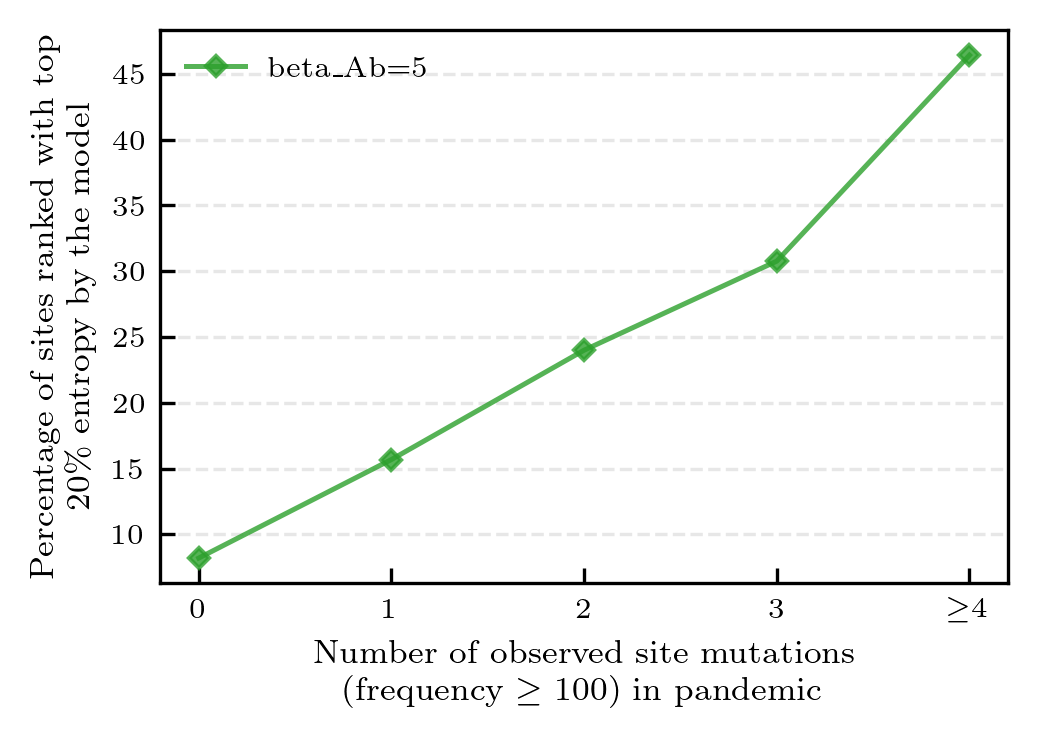

In [8]:

# import Proteins_utils # Assuming this is imported in your environment

# --- CONFIGURATION ---
GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
SITE_OFFSET = 349  # The starting residue number (index 0 = site 349)
ENTROPY_PERCENTILE = 80 # Top 10%
# ---------------------

# Style settings
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 600,
    "axes.linewidth": 0.8, "lines.linewidth": 1.2, "lines.markersize": 3.5,
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "text.usetex": True
})

# 1. Load and Preprocess GISAID Data (Observed counts per site)
# -------------------------------------------------------
print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)
df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

# Filter: seen at least 100 times
df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

# Extract site number from mutation string (e.g., "A349C" -> 349)
# Assuming format is [WT][Site][Mut]
def extract_site(mut_str):
    try:
        return int(mut_str[1:-1])
    except:
        return -1

df_seen['site_num'] = df_seen['mutation'].apply(extract_site)

# Count unique amino acid variations observed per site
# (e.g., if site 484 has E484K and E484Q, count is 2)
observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()

# 2. Compute Entropy and Perform Binning Analysis
# -------------------------------------------------------
path_entropies_all = {} 
bin_results = {} # condition -> {bin_label: percentage}

# Bins definition
bins_labels = [0, 1, 2, 3, 4] # 4 represents >=4

for i, condition in enumerate(labels):
    print(f"Processing: {condition}")
    
    # Load data (Shape: Q, T, L)
    path_proba = np.load(os.path.join(dir, paths[i])) 
    
    # --- Compute Entropy at Last Step ---
    last_step_probs = path_proba[:, -1, :] # (Vocab, Length)
    epsilon = 1e-12
    # Entropy per site
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
    # --- Define "Top 10%" Threshold ---
    threshold_val = np.percentile(site_entropies, ENTROPY_PERCENTILE)
    is_high_entropy = site_entropies >= threshold_val
    
    # --- Binning Logic ---
    # Buckets to store: [total_sites_in_bin, high_entropy_sites_in_bin]
    # Key is 0, 1, 2, 3, 4 (where 4 is >=4)
    bin_counts = {b: [0, 0] for b in bins_labels}
    
    # Iterate over every site in the simulated sequence
    for array_idx in range(len(site_entropies)):
        real_site_num = SITE_OFFSET + array_idx
        
        # Get real-world observed count (default to 0 if not found)
        obs_count = observed_counts_map.get(real_site_num, 0)
        
        # Cap at 4 for the binning
        bin_idx = min(obs_count, 4)
        
        # Update totals
        bin_counts[bin_idx][0] += 1 # Increment total sites in this bin
        if is_high_entropy[array_idx]:
            bin_counts[bin_idx][1] += 1 # Increment high entropy sites
            
    # Calculate percentages
    # percentages[bin] = (high_ent / total) * 100
    percentages = []
    for b in bins_labels:
        total = bin_counts[b][0]
        high = bin_counts[b][1]
        pct = (high / total * 100.0) if total > 0 else 0.0
        percentages.append(pct)
        
    bin_results[condition] = percentages

# 3. Plotting
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(3.5, 2.5))

markers = ["o", "^", "D", "s", "v"]
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"] 

x_indices = range(len(bins_labels))
xtick_labels = ["0", "1", "2", "3", "$\ge$4"]

for i, (condition, y_values) in enumerate(bin_results.items()):
    if condition!="beta_Ab=5":
     continue
    style_idx = i % len(markers)
    ax.plot(x_indices, y_values, 
            marker=markers[style_idx], 
            label=condition,
            color=colors[style_idx],
            alpha=0.8)

# Formatting
ax.set_xticks(x_indices)
ax.set_xticklabels(xtick_labels)
ax.set_xlabel("Number of observed site mutations\n(frequency $\ge$ 100) in pandemic")
ax.set_ylabel(f"Percentage of sites ranked with top\n{100-ENTROPY_PERCENTILE}\% entropy by the model")

ax.tick_params(direction="in", which="both", top=False, right=False)
ax.legend(frameon=False, loc="best")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

<>:118: SyntaxWarning: invalid escape sequence '\%'
<>:119: SyntaxWarning: invalid escape sequence '\g'
<>:118: SyntaxWarning: invalid escape sequence '\%'
<>:119: SyntaxWarning: invalid escape sequence '\g'
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\827305198.py:118: SyntaxWarning: invalid escape sequence '\%'
  ax.set_xlabel("Model site entropy percentile rank (\%)")
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\827305198.py:119: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel("Average observed site\nmutations (frequency $\ge$ 100)")
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\827305198.py:126: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="best")


Loading GISAID summary...
Processing: beta_Ab=0
Processing: beta_Ab=1
Processing: beta_Ab=5


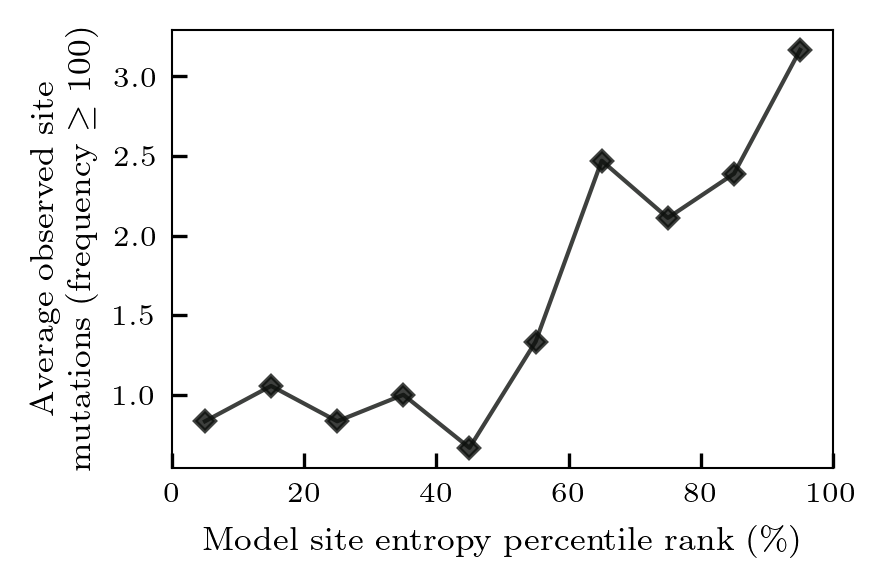

In [9]:

# import Proteins_utils # Assuming this is imported in your environment

# --- CONFIGURATION ---
GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
SITE_OFFSET = 349  # The starting residue number (index 0 = site 349)
N_BINS = 10        # Number of bins for X-axis (e.g., 10 = deciles)
# ---------------------

# Style settings
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 600,
    "axes.linewidth": 0.5, "lines.linewidth": 1., "lines.markersize": 3.5,
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "text.usetex": True
})

# 1. Load and Preprocess GISAID Data (Observed counts per site)
# -------------------------------------------------------
print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)
df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

# Filter: seen at least 100 times
df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

# Extract site number from mutation string (e.g., "A349C" -> 349)
def extract_site(mut_str):
    try:
        return int(mut_str[1:-1])
    except:
        return -1

df_seen['site_num'] = df_seen['mutation'].apply(extract_site)

# Count unique amino acid variations observed per site
# (e.g., if site 484 has E484K and E484Q, count is 2)
observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()

# 2. Compute Entropy and Perform Ranking/Binning Analysis
# -------------------------------------------------------
plot_data = {} # condition -> (x_values, y_values)

for i, condition in enumerate(labels):
    print(f"Processing: {condition}")
    
    # Load data (Shape: Q, T, L)
    path_proba = np.load(os.path.join(dir, paths[i])) 
    
    # --- Compute Entropy at Last Step ---
    last_step_probs = path_proba[:, -1, :] # (Vocab, Length)
    epsilon = 1e-12
    # Entropy per site
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
    # --- Compute Ranking Percentile (0 to 100) ---
    # argsort twice gives the rank of each element
    ranks = np.argsort(np.argsort(site_entropies))
    n_sites = len(site_entropies)
    # Normalize ranks to 0-100 range
    percentiles = (ranks / (n_sites - 1)) * 100
    
    # --- Binning Logic ---
    # We bin the sites based on their percentile rank
    bin_edges = np.linspace(0, 100, N_BINS + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    bin_means = []
    
    for b in range(N_BINS):
        low, high = bin_edges[b], bin_edges[b+1]
        
        # Identify sites in this percentile bin
        # Handle the last bin inclusively (<= 100)
        if b == N_BINS - 1:
            mask = (percentiles >= low) & (percentiles <= high)
        else:
            mask = (percentiles >= low) & (percentiles < high)
            
        site_indices = np.where(mask)[0]
        
        # Collect observed mutation counts for these sites
        counts_in_bin = []
        for idx in site_indices:
            real_site_num = SITE_OFFSET + idx
            # Default to 0 if site not found in GISAID map
            counts_in_bin.append(observed_counts_map.get(real_site_num, 0))
            
        # Compute mean observed count for this bin
        if len(counts_in_bin) > 0:
            bin_means.append(np.mean(counts_in_bin))
        else:
            bin_means.append(np.nan)
            
    plot_data[condition] = (bin_centers, bin_means)

# 3. Plotting
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(3., 2.), dpi=300)

markers = ["o", "^", "D", "s", "v"]
colors  = ["#1f77b4", "#ff7f0e", "#0d100d", "#d62728", "#9467bd"] 

for i, (condition, (x_vals, y_vals)) in enumerate(plot_data.items()):
    # Remove this filter if you want to see all conditions
    if condition != "beta_Ab=5":
        continue
        
    style_idx = i % len(markers)
    ax.plot(x_vals, y_vals, 
            marker=markers[style_idx], 
            # label=condition,
            color=colors[style_idx],
            alpha=0.8)

# Formatting
ax.set_xlabel("Model site entropy percentile rank (\%)")
ax.set_ylabel("Average observed site\nmutations (frequency $\ge$ 100)")

# Set X-axis to standard 0-100 range
ax.set_xlim(0, 100)
ax.set_xticks(np.arange(0, 101, 20))

ax.tick_params(direction="in", which="both", top=False, right=False)
ax.legend(frameon=False, loc="best")
# ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:

# # import Proteins_utils # Assuming this is imported in your environment

# # --- CONFIGURATION ---
# GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
# SITE_OFFSET = 349  # The starting residue number (index 0 = site 349)
# N_BINS = 10        # Number of bins for X-axis (e.g., 10 = deciles)
# # ---------------------

# # Style settings
# mpl.rcParams.update({
#     "figure.dpi": 300, "savefig.dpi": 600,
#     "axes.linewidth": 0.5, "lines.linewidth": 1., "lines.markersize": 3.5,
#     "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
#     "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
#     "pdf.fonttype": 42, "ps.fonttype": 42,
#     "text.usetex": True
# })

# # 1. Load and Preprocess GISAID Data (Observed counts per site)
# # -------------------------------------------------------
# print("Loading GISAID summary...")
# df_base = pd.read_csv(GISAID_PATH)
# df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

# # Filter: seen at least 100 times
# df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

# # Extract site number from mutation string (e.g., "A349C" -> 349)
# def extract_site(mut_str):
#     try:
#         return int(mut_str[1:-1])
#     except:
#         return -1

# df_seen['site_num'] = df_seen['mutation'].apply(extract_site)

# # Count unique amino acid variations observed per site
# # (e.g., if site 484 has E484K and E484Q, count is 2)
# observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()

# # 2. Compute Entropy and Perform Ranking/Binning Analysis
# # -------------------------------------------------------
# plot_data = {} # condition -> (x_values, y_values)

# for i, condition in enumerate(labels):
#     print(f"Processing: {condition}")
    
#     # Load data (Shape: Q, T, L)
#     path_proba = np.load(os.path.join(dir, paths[i])) 
    
#     # --- Compute Entropy at Last Step ---
#     last_step_probs = path_proba[:, -1, :] # (Vocab, Length)
#     epsilon = 1e-12
#     # Entropy per site
#     site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
#     # --- Compute Ranking Percentile (0 to 100) ---
#     # argsort twice gives the rank of each element
#     ranks = np.argsort(np.argsort(site_entropies))
#     n_sites = len(site_entropies)
#     # Normalize ranks to 0-100 range
#     percentiles = (ranks / (n_sites - 1)) * 100
    
#     # --- Binning Logic ---
#     # We bin the sites based on their percentile rank
#     bin_edges = np.linspace(0, 100, N_BINS + 1)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
#     bin_means = []
    
#     for b in range(N_BINS):
#         low, high = bin_edges[b], bin_edges[b+1]
        
#         # Identify sites in this percentile bin
#         # Handle the last bin inclusively (<= 100)
#         if b == N_BINS - 1:
#             mask = (percentiles >= low) & (percentiles <= high)
#         else:
#             mask = (percentiles >= low) & (percentiles < high)
            
#         site_indices = np.where(mask)[0]
        
#         # Collect observed mutation counts for these sites
#         counts_in_bin = []
#         for idx in site_indices:
#             real_site_num = SITE_OFFSET + idx
#             # Default to 0 if site not found in GISAID map
#             counts_in_bin.append(observed_counts_map.get(real_site_num, 0))
            
#         # Compute mean observed count for this bin
#         if len(counts_in_bin) > 0:
#             bin_means.append(np.mean(counts_in_bin))
#         else:
#             bin_means.append(np.nan)
            
#     plot_data[condition] = (bin_centers, bin_means)

# # 3. Plotting
# # -------------------------------------------------------
# fig, ax = plt.subplots(figsize=(3., 2.), dpi=300)

# markers = ["o", "^", "D", "s", "v"]
# colors  = ["#1f77b4", "#ff7f0e", "#0d100d", "#d62728", "#9467bd"] 

# for i, (condition, (x_vals, y_vals)) in enumerate(plot_data.items()):
#     # Remove this filter if you want to see all conditions
#     if condition != "beta_Ab=5":
#         continue
        
#     style_idx = i % len(markers)
#     ax.plot(x_vals, y_vals, 
#             marker=markers[style_idx], 
#             # label=condition,
#             color=colors[style_idx],
#             alpha=0.8)

# # Formatting
# ax.set_xlabel("Model site entropy percentile rank (\%)")
# ax.set_ylabel("Average observed site\nmutations (frequency $\ge$ 100)")

# # Set X-axis to standard 0-100 range
# ax.set_xlim(0, 100)
# ax.set_xticks(np.arange(0, 101, 20))

# ax.tick_params(direction="in", which="both", top=False, right=False)
# ax.legend(frameon=False, loc="best")
# # ax.grid(axis='y', linestyle='--', alpha=0.3)

# plt.tight_layout()
# plt.show()

<>:92: SyntaxWarning: invalid escape sequence '\g'
<>:92: SyntaxWarning: invalid escape sequence '\g'
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\3496634741.py:92: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel("Observed unique mutations\n(frequency $\ge$ 100)")


Loading GISAID summary...
Processing: beta_Ab=0
Processing: beta_Ab=1
Processing: beta_Ab=5


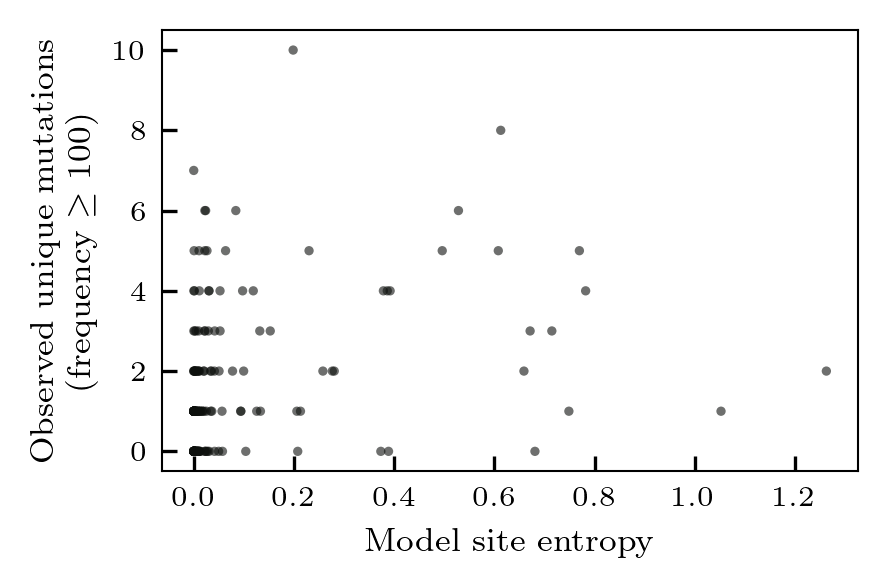

In [11]:

# --- CONFIGURATION ---
GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
SITE_OFFSET = 349  # The starting residue number (index 0 = site 349)
# N_BINS is no longer needed
# ---------------------

# Style settings
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 600,
    "axes.linewidth": 0.5, "lines.linewidth": 1., "lines.markersize": 3.5,
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "text.usetex": True
})

# 1. Load and Preprocess GISAID Data (Observed counts per site)
# -------------------------------------------------------
print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)
df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

# Filter: seen at least 100 times
df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

# Extract site number from mutation string (e.g., "A349C" -> 349)
def extract_site(mut_str):
    try:
        return int(mut_str[1:-1])
    except:
        return -1

df_seen['site_num'] = df_seen['mutation'].apply(extract_site)

# Count unique amino acid variations observed per site
observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()

# 2. Compute Entropy and Collect Site Data (No Averaging)
# -------------------------------------------------------
plot_data = {} # condition -> (x_values, y_values)

for i, condition in enumerate(labels):
    print(f"Processing: {condition}")
    
    # Load data (Shape: Q, T, L)
    path_proba = np.load(os.path.join(dir, paths[i])) 
    
    # --- Compute Entropy at Last Step ---
    last_step_probs = path_proba[:, -1, :] # (Vocab, Length)
    epsilon = 1e-12
    # Entropy per site
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
    # --- Map Entropies to Observed Counts ---
    # Create arrays for plotting: X = Entropy, Y = Observed Mutation Count
    x_points = site_entropies
    y_points = []
    
    for idx in range(len(site_entropies)):
        real_site_num = SITE_OFFSET + idx
        # Get count from GISAID map, default to 0 if no mutations seen
        count = observed_counts_map.get(real_site_num, 0)
        y_points.append(count)
    
    y_points = np.array(y_points)
            
    plot_data[condition] = (x_points, y_points)

# 3. Plotting
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(3., 2.), dpi=300)

colors  = ["#1f77b4", "#ff7f0e", "#0d100d", "#d62728", "#9467bd"] 

for i, (condition, (x_vals, y_vals)) in enumerate(plot_data.items()):
    # Remove this filter if you want to see all conditions
    if condition != "beta_Ab=5":
        continue
        
    style_idx = i % len(colors)
    
    # Scatter plot: each point is a site
    ax.scatter(x_vals, y_vals, 
               s=5, # Smaller point size for scatter
               color=colors[style_idx],
               alpha=0.6,
               edgecolors='none', # Optional: remove edge for cleaner look
               label=condition)

# Formatting
ax.set_xlabel("Model site entropy")
ax.set_ylabel("Observed unique mutations\n(frequency $\ge$ 100)")

ax.tick_params(direction="in", which="both", top=False, right=False)

# Optional: Adjust legend or remove if too many points make it cluttered
# ax.legend(frameon=False, loc="best")

plt.tight_layout()
plt.show()

<>:99: SyntaxWarning: invalid escape sequence '\g'
<>:99: SyntaxWarning: invalid escape sequence '\g'
C:\Users\maria\AppData\Local\Temp\ipykernel_16804\2261986687.py:99: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title(f"Prediction of Sites with $\ge$ {THRESHOLD_COUNT} Mutations")


Loading GISAID summary...
Processing: beta_Ab=0
Processing: beta_Ab=1
Processing: beta_Ab=5


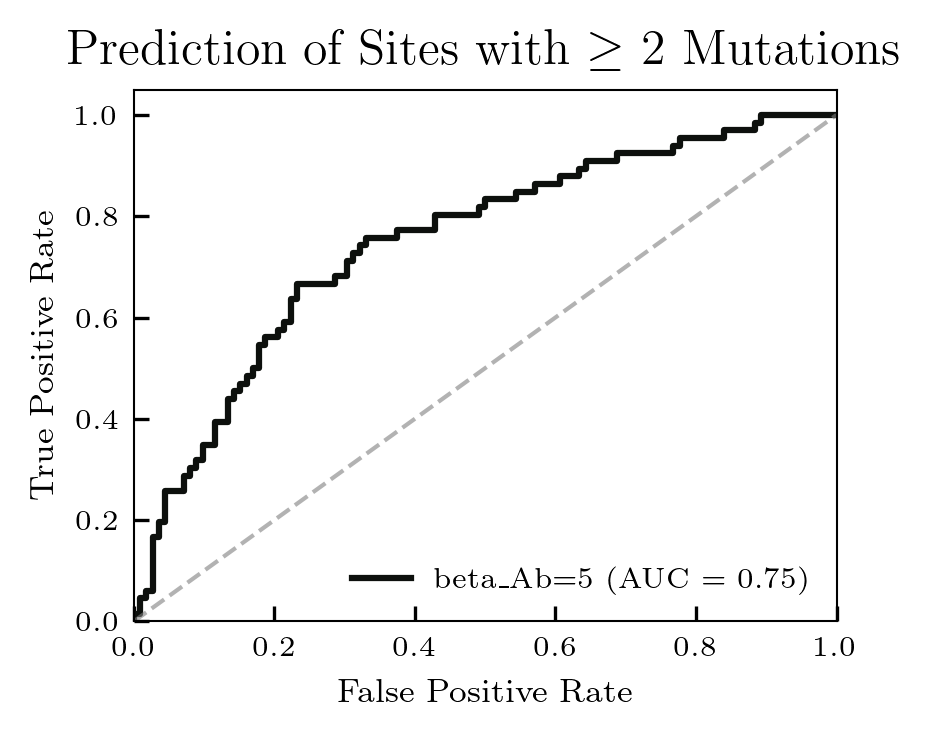

In [12]:
# --- CONFIGURATION ---
GISAID_PATH = "../covid/gisaid/all_mutation_summary.csv"
SITE_OFFSET = 349  # The starting residue number (index 0 = site 349)
THRESHOLD_COUNT = 2 # Label 1 if observed counts >= this value
# ---------------------

# Style settings
mpl.rcParams.update({
    "figure.dpi": 300, "savefig.dpi": 600,
    "axes.linewidth": 0.5, "lines.linewidth": 1., "lines.markersize": 3.5,
    "font.size": 8, "axes.labelsize": 8, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 7, "font.family": "serif", "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "text.usetex": True
})

# 1. Load and Preprocess GISAID Data
# -------------------------------------------------------
print("Loading GISAID summary...")
df_base = pd.read_csv(GISAID_PATH)
df_base["first_seen_100"] = pd.to_datetime(df_base["first_seen_100"], errors='coerce')

# Filter: seen at least 100 times
df_seen = df_base.dropna(subset=["first_seen_100"]).copy()

# Extract site number
def extract_site(mut_str):
    try:
        return int(mut_str[1:-1])
    except:
        return -1

df_seen['site_num'] = df_seen['mutation'].apply(extract_site)

# Count unique amino acid variations observed per site
observed_counts_map = df_seen.groupby('site_num')['mutation'].nunique().to_dict()

# 2. Compute Entropy and ROC Statistics
# -------------------------------------------------------
plot_data = {} # condition -> (fpr, tpr, auc_score)

for i, condition in enumerate(labels):
    print(f"Processing: {condition}")
    
    # Load data
    path_proba = np.load(os.path.join(dir, paths[i])) 
    
    # --- Compute Entropy (Predictor Score) ---
    last_step_probs = path_proba[:, -1, :] 
    epsilon = 1e-12
    site_entropies = -np.sum(last_step_probs * np.log(last_step_probs + epsilon), axis=0)
    
    # --- Generate Binary Labels (Target) ---
    y_true = []
    y_scores = site_entropies
    
    for idx in range(len(site_entropies)):
        real_site_num = SITE_OFFSET + idx
        count = observed_counts_map.get(real_site_num, 0)
        
        # Label is 1 if at least 2 unique mutations observed
        if count >= THRESHOLD_COUNT:
            y_true.append(1)
        else:
            y_true.append(0)
            
    y_true = np.array(y_true)
    
    # --- Calculate ROC ---
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plot_data[condition] = (fpr, tpr, roc_auc)

# 3. Plotting
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(3., 2.5), dpi=300)

colors  = ["#1f77b4", "#ff7f0e", "#0d100d", "#d62728", "#9467bd"] 

for i, (condition, (fpr, tpr, roc_auc)) in enumerate(plot_data.items()):
    # Remove this filter if you want to see all conditions
    if condition != "beta_Ab=5":
        continue
        
    style_idx = i % len(colors)
    
    ax.plot(fpr, tpr, 
            color=colors[style_idx],
            label=f"{condition} (AUC = {roc_auc:.2f})",
            lw=1.5)

# Add diagonal random chance line
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.6)

# Formatting
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title(f"Prediction of Sites with $\ge$ {THRESHOLD_COUNT} Mutations")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

ax.tick_params(direction="in", which="both", top=False, right=False)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()